# EDA — CIC-IDS-2017 Dataset

**Phase 1 du PLAN.md** — Comprendre les données interactivement AVANT de modéliser.

Questions auxquelles ce notebook répond :
1. Combien de lignes par classe ?
2. Comment sont distribuées les features clés (durée, paquets, débit) par classe ?
3. **Le shortcut learning sur `Destination Port` est-il bien réel ?** (preuve visuelle)
4. Y a-t-il des features fortement corrélées (multi-colinéarité) ?
5. Quelles valeurs aberrantes faut-il nettoyer ?
6. Quelles règles de nettoyage appliquer en Phase 2 ?

## 0. Setup

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)

DATA = Path('../data/cicids2017.csv')
OUT = Path('../results/eda')
OUT.mkdir(parents=True, exist_ok=True)

print(f'CSV existe : {DATA.exists()}')

CSV existe : True


## 1. Chargement

In [2]:
df = pd.read_csv(DATA)
print(f'Lignes : {len(df):,}')
print(f'Colonnes : {df.shape[1]}')
print(f'Mémoire : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
df.head(2)

Lignes : 2,520,751
Colonnes : 53
Mémoire : 1100.5 MB


,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,PSH Flag Count,ACK Flag Count,Average Packet Size,Subflow Fwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min,Attack Type
0,22,1266342,41,2664,456,0,64.97561,109.864573,976,0,158.045455,312.67525,7595.10464,67.122468,15075.50000,104051.3997,948537,0,1266342,31658.550,159355.2595,996324,2,317671,7387.697674,19636.44809,104616,1,1328,1424,32.376720,34.745748,0,976,111.837209,239.686848,57449.78495,0,1,0,113.152941,2664,29200,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
1,22,1319353,41,2664,456,0,64.97561,109.864573,976,0,158.045455,312.67525,7289.93681,64.425518,15706.58333,104861.8701,955790,1,1319353,32983.825,159247.9008,996423,1,363429,8451.837209,21337.26261,104815,1,1328,1424,31.075838,33.349680,0,976,111.837209,239.686848,57449.78495,0,1,0,113.152941,2664,29200,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic


## 2. Distribution des classes

In [18]:
counts = df['Attack Type'].value_counts()
pct = (counts / len(df) * 100).round(3)
summary = pd.DataFrame({'count': counts, 'pct': pct})
print(summary.to_string())
print(f'\nDéséquilibre Normal/Bots : {counts.iloc[0] / counts.iloc[-1]:.1f} : 1')

                  count     pct
Attack Type                    
Normal Traffic  2095057  83.112
DoS              193745   7.686
DDoS             128014   5.078
Port Scanning     90694   3.598
Brute Force        9150   0.363
Web Attacks        2143   0.085
Bots               1948   0.077

Déséquilibre Normal/Bots : 1075.5 : 1


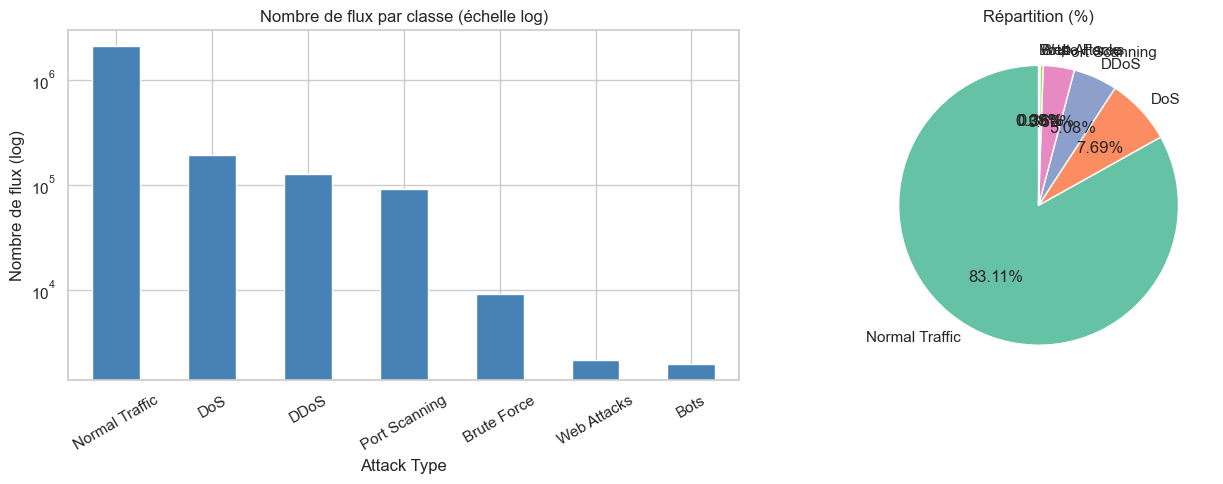

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart (log scale car déséquilibre énorme)
counts.plot.bar(ax=axes[0], color='steelblue', logy=True)
axes[0].set_title('Nombre de flux par classe (échelle log)')
axes[0].set_ylabel('Nombre de flux (log)')
axes[0].tick_params(axis='x', rotation=30)

# Pie chart
counts.plot.pie(ax=axes[1], autopct='%1.2f%%', startangle=90,
                colors=sns.color_palette('Set2', n_colors=7))
axes[1].set_title('Répartition (%)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(OUT / 'class_distribution.png', dpi=110, bbox_inches='tight')
plt.show()

## 3. Anomalies & nettoyage

In [19]:
print('=== VALEURS MANQUANTES ===')
na = df.isna().sum()
print(f'Total NaN : {na.sum()}')

print('\n=== VALEURS INFINIES ===')
num_cols = df.select_dtypes(include=[np.number]).columns
inf_count = np.isinf(df[num_cols]).sum().sum()
print(f'Total Inf : {inf_count}')

print('\n=== VALEURS NÉGATIVES SUSPECTES ===')
for col in ['Flow Bytes/s', 'Flow Packets/s', 'Flow Duration']:
    n_neg = (df[col] < 0).sum()
    if n_neg > 0:
        print(f'  {col} : {n_neg} valeurs < 0, min = {df[col].min():,.0f}')

print('\n=== FEATURES À VARIANCE NULLE ===')
zero_var = df[num_cols].var()[df[num_cols].var() == 0]
print(f'Features constantes : {len(zero_var)}')

=== VALEURS MANQUANTES ===
Total NaN : 0

=== VALEURS INFINIES ===
Total Inf : 0

=== VALEURS NÉGATIVES SUSPECTES ===
  Flow Bytes/s : 78 valeurs < 0, min = -261,000,000
  Flow Packets/s : 107 valeurs < 0, min = -2,000,000
  Flow Duration : 107 valeurs < 0, min = -13

=== FEATURES À VARIANCE NULLE ===
Features constantes : 0


## 4. Statistiques de features clés par classe

In [20]:
key_features = ['Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets',
                'Flow Bytes/s', 'Flow Packets/s', 'Average Packet Size']

for feat in key_features:
    print(f'\n=== {feat} (médiane par classe) ===')
    stats = df.groupby('Attack Type')[feat].agg(['median', 'mean', 'std']).round(2)
    print(stats.to_string())


=== Flow Duration (médiane par classe) ===
                    median         mean          std
Attack Type                                         
Bots               71035.5    354185.44   1977614.45
Brute Force      9114177.0   7891160.13   5006679.98
DDoS             1879121.5  16957157.95  31013786.10
DoS             85872118.0  72634739.58  38796208.10
Normal Traffic     39979.0  12160238.43  31183825.62
Port Scanning         50.0    145096.46   3077444.45
Web Attacks      5487328.0   6646525.88   7507220.14

=== Total Fwd Packets (médiane par classe) ===
                median   mean     std
Attack Type                          
Bots               3.0   3.21    4.03
Brute Force        9.0  11.21    7.47
DDoS               4.0   4.47    1.90
DoS                6.0   6.34    2.32
Normal Traffic     2.0  11.38  871.35
Port Scanning      1.0   1.03    0.56
Web Attacks        3.0  11.12   39.44

=== Total Length of Fwd Packets (médiane par classe) ===
                median     mean

C:\Users\DELL LATITUDE U7\AppData\Local\Temp\ipykernel_24424\904403609.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Attack Type', y='Flow Duration log', ax=axes[0],
C:\Users\DELL LATITUDE U7\AppData\Local\Temp\ipykernel_24424\904403609.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Attack Type', y='Pkts log', ax=axes[1],


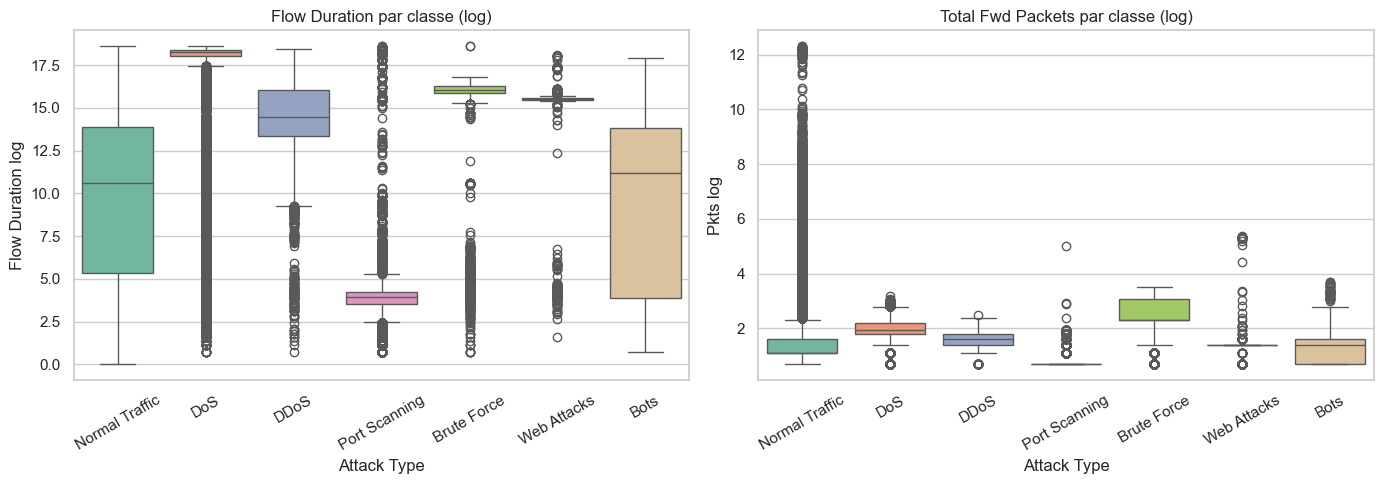

In [7]:
# Boxplot Flow Duration par classe (log scale)
df_plot = df.copy()
df_plot['Flow Duration log'] = np.log1p(df_plot['Flow Duration'].clip(lower=0))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df_plot, x='Attack Type', y='Flow Duration log', ax=axes[0],
            order=counts.index, palette='Set2')
axes[0].set_title('Flow Duration par classe (log)')
axes[0].tick_params(axis='x', rotation=30)

df_plot['Pkts log'] = np.log1p(df_plot['Total Fwd Packets'].clip(lower=0))
sns.boxplot(data=df_plot, x='Attack Type', y='Pkts log', ax=axes[1],
            order=counts.index, palette='Set2')
axes[1].set_title('Total Fwd Packets par classe (log)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(OUT / 'feature_distributions.png', dpi=110, bbox_inches='tight')
plt.show()

## 5. ⚠️ Le test du shortcut learning — Destination Port

On veut prouver **visuellement** que `Destination Port` encode déjà la classe pour 4 familles d'attaque sur 7.

In [8]:
print('=== PORTS UNIQUES PAR CLASSE ===\n')
for cls in df['Attack Type'].value_counts().index:
    ports = df[df['Attack Type'] == cls]['Destination Port']
    nu = ports.nunique()
    top3 = ports.value_counts().head(3)
    n = len(ports)
    detail = ', '.join([f'port {int(p)}={c/n*100:.1f}%' for p, c in top3.items()])
    print(f'{cls:18} : {nu:>5} ports distincts | top3 : {detail}')

=== PORTS UNIQUES PAR CLASSE ===

Normal Traffic     : 53788 ports distincts | top3 : port 53=41.9%, port 443=22.4%, port 80=10.4%
DoS                :     1 ports distincts | top3 : port 80=100.0%
DDoS               :     4 ports distincts | top3 : port 80=100.0%, port 64869=0.0%, port 64873=0.0%
Port Scanning      :  1000 ports distincts | top3 : port 80=0.4%, port 22=0.3%, port 21=0.3%
Brute Force        :     3 ports distincts | top3 : port 21=64.8%, port 22=35.2%, port 80=0.0%
Web Attacks        :     1 ports distincts | top3 : port 80=100.0%
Bots               :   702 ports distincts | top3 : port 8080=64.0%, port 1841=0.1%, port 1845=0.1%


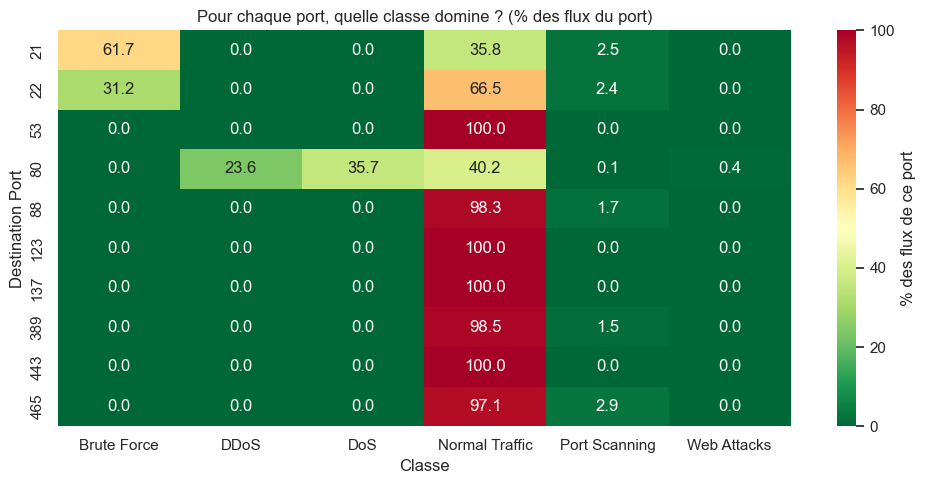

In [9]:
# Heatmap : pour les 10 ports les plus fréquents globalement, quelle classe domine ?
top_ports = df['Destination Port'].value_counts().head(10).index.tolist()
ct = pd.crosstab(df[df['Destination Port'].isin(top_ports)]['Destination Port'],
                 df[df['Destination Port'].isin(top_ports)]['Attack Type'])
# Normaliser en %
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(ct_pct, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=ax,
            cbar_kws={'label': '% des flux de ce port'})
ax.set_title('Pour chaque port, quelle classe domine ? (% des flux du port)')
ax.set_xlabel('Classe')
ax.set_ylabel('Destination Port')
plt.tight_layout()
plt.savefig(OUT / 'port_vs_class_heatmap.png', dpi=110, bbox_inches='tight')
plt.show()

In [10]:
# Test isolé : un modèle qui ne voit QUE Destination Port
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, classification_report

# Sample stratifié pour aller vite (300k lignes)
samples = []
for cls in df['Attack Type'].unique():
    sub = df[df['Attack Type'] == cls]
    samples.append(sub.sample(min(50000, len(sub)), random_state=42))
df_s = pd.concat(samples).reset_index(drop=True)
print(f'Sample stratifié : {len(df_s):,} lignes\n')

y = df_s['Attack Type'].values

# Test 1 : Destination Port SEUL
X = df_s[['Destination Port']].values
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
rf = RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)
rf.fit(Xtr, ytr)
y_pred = rf.predict(Xte)
print(f'AVEC UNIQUEMENT "Destination Port" :')
print(f'  Accuracy     : {accuracy_score(yte, y_pred):.4f}')
print(f'  F1 weighted  : {f1_score(yte, y_pred, average="weighted"):.4f}')
print(f'  F1 macro     : {f1_score(yte, y_pred, average="macro"):.4f}')
print('\nDétail par classe :')
print(classification_report(yte, y_pred, digits=4))

Sample stratifié : 213,241 lignes



TypeError: only integer scalar arrays can be converted to a scalar index

In [11]:
# Test 2 : 5 features comportementales (SANS Destination Port)
behavior_features = ['Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets',
                     'Flow Bytes/s', 'Flow Packets/s']
X = df_s[behavior_features].replace([np.inf, -np.inf], np.nan).fillna(0).values
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
rf = RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)
rf.fit(Xtr, ytr)
y_pred = rf.predict(Xte)
print(f'AVEC 5 features comportementales (SANS port) :')
print(f'  Accuracy     : {accuracy_score(yte, y_pred):.4f}')
print(f'  F1 weighted  : {f1_score(yte, y_pred, average="weighted"):.4f}')
print(f'  F1 macro     : {f1_score(yte, y_pred, average="macro"):.4f}')
print('\nDétail par classe :')
print(classification_report(yte, y_pred, digits=4))

TypeError: only integer scalar arrays can be converted to a scalar index

## 6. Corrélations entre features

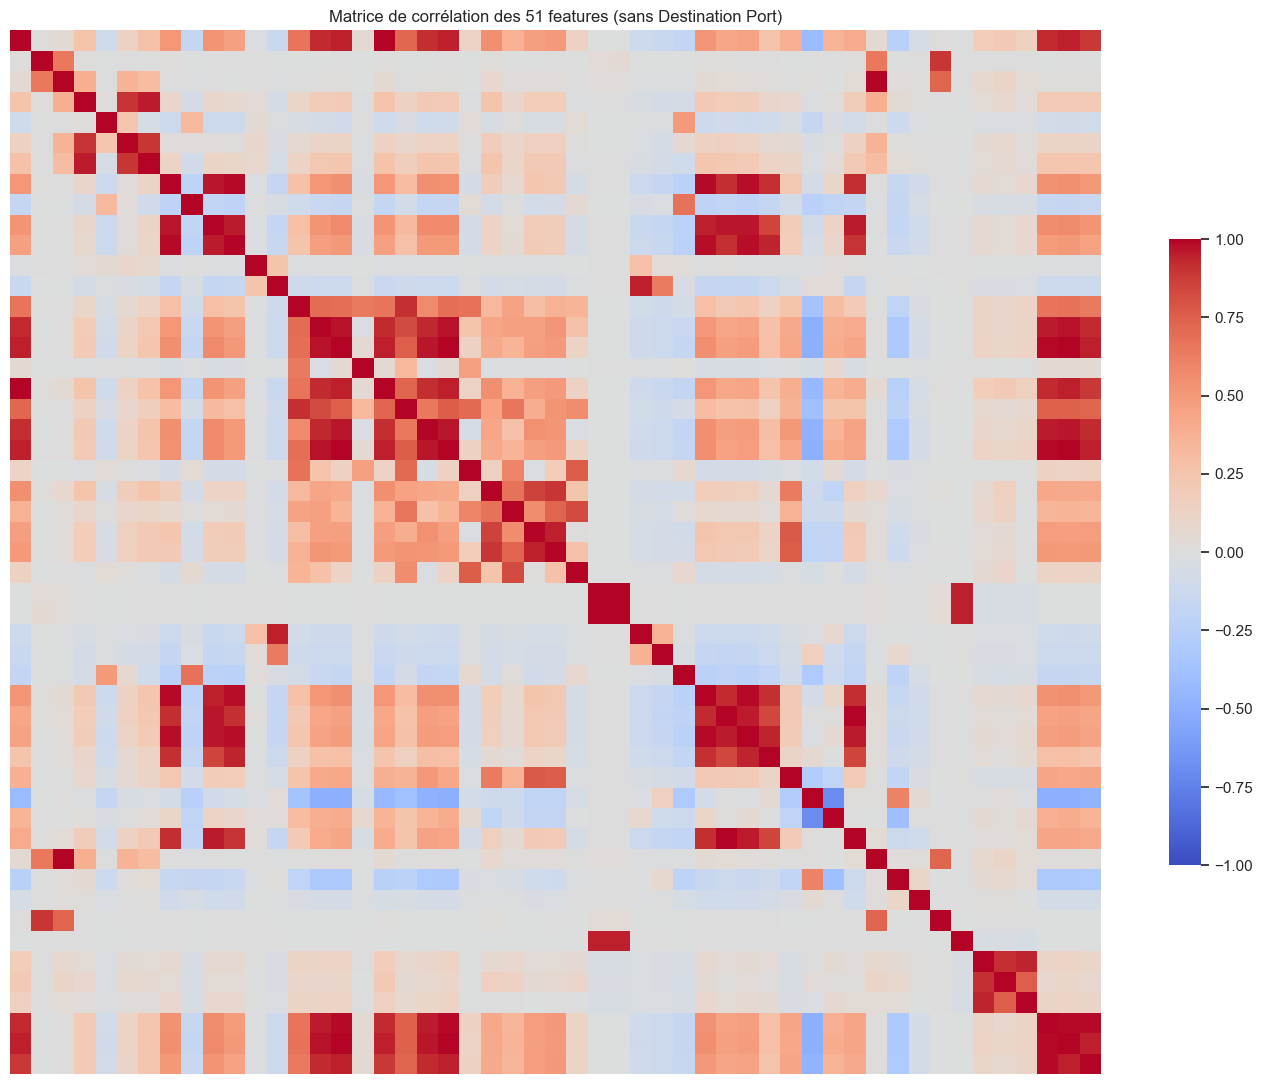

Top 15 paires de features très corrélées (|corr| > 0.95) :
  1.000  Fwd Header Length                   ↔ Bwd Header Length
  1.000  Flow IAT Max                        ↔ Fwd IAT Max
  0.999  Fwd IAT Total                       ↔ Flow Duration
  0.999  Average Packet Size                 ↔ Packet Length Mean
  0.998  Flow IAT Max                        ↔ Idle Max
  0.998  Fwd IAT Max                         ↔ Idle Max
  0.992  Bwd Packet Length Max               ↔ Max Packet Length
  0.990  Bwd Packet Length Std               ↔ Bwd Packet Length Max
  0.987  Idle Max                            ↔ Idle Mean
  0.987  Idle Mean                           ↔ Idle Min
  0.986  Packet Length Std                   ↔ Max Packet Length
  0.985  Flow IAT Max                        ↔ Idle Mean
  0.985  Fwd IAT Max                         ↔ Idle Mean
  0.983  Bwd Packet Length Std               ↔ Packet Length Std
  0.981  Max Packet Length                   ↔ Bwd Packet Length Std


In [12]:
# Calcul sur sample pour vitesse
num_cols_no_port = [c for c in num_cols if c != 'Destination Port']
corr = df_s[num_cols_no_port].replace([np.inf, -np.inf], np.nan).fillna(0).corr()

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax, vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.6}, xticklabels=False, yticklabels=False)
ax.set_title('Matrice de corrélation des 51 features (sans Destination Port)')
plt.tight_layout()
plt.savefig(OUT / 'correlation_heatmap.png', dpi=110, bbox_inches='tight')
plt.show()

# Top paires très corrélées
corr_pairs = corr.abs().unstack().sort_values(ascending=False)
# Filtrer diagonale et doublons
corr_pairs = corr_pairs[corr_pairs < 1.0]
seen = set()
high_corr = []
for (a, b), v in corr_pairs.items():
    if (b, a) in seen or a == b:
        continue
    seen.add((a, b))
    if v > 0.95:
        high_corr.append((a, b, v))
    if len(high_corr) >= 15:
        break

print('Top 15 paires de features très corrélées (|corr| > 0.95) :')
for a, b, v in high_corr:
    print(f'  {v:.3f}  {a:35} ↔ {b}')

## 7. Sauvegarde du résumé EDA

In [14]:
summary = {
    'total_rows': int(len(df)),
    'total_columns': int(df.shape[1]),
    'memory_mb': round(df.memory_usage(deep=True).sum() / 1e6, 1),
    'classes': {cls: int(c) for cls, c in counts.items()},
    'class_pct': {cls: float(p) for cls, p in pct.items()},
    'imbalance_ratio_max': float(counts.iloc[0] / counts.iloc[-1]),
    'anomalies': {
        'nan_count': int(na.sum()),
        'inf_count': int(inf_count),
        'flow_bytes_negatives': int((df['Flow Bytes/s'] < 0).sum()),
        'zero_variance_features': int(len(zero_var)),
    },
    'cleaning_rules': [
        'Drop column Destination Port',
        'Clip Flow Bytes/s lower bound to 0',
        'Replace Inf with 0 if any',
    ],
    'high_correlation_pairs_over_0_95': [
        {'a': a, 'b': b, 'corr': float(v)} for a, b, v in high_corr
    ],
}
(OUT / 'eda_summary.json').write_text(json.dumps(summary, indent=2), encoding='utf-8')
print('Sauvegardé :', OUT / 'eda_summary.json')
print(json.dumps(summary, indent=2)[:1200] + '...')

Sauvegardé : ..\results\eda\eda_summary.json
{
  "total_rows": 2520751,
  "total_columns": 53,
  "memory_mb": 1100.5,
  "classes": {
    "Normal Traffic": 2095057,
    "DoS": 193745,
    "DDoS": 128014,
    "Port Scanning": 90694,
    "Brute Force": 9150,
    "Web Attacks": 2143,
    "Bots": 1948
  },
  "class_pct": {
    "Normal Traffic": 83.112,
    "DoS": 7.686,
    "DDoS": 5.078,
    "Port Scanning": 3.598,
    "Brute Force": 0.363,
    "Web Attacks": 0.085,
    "Bots": 0.077
  },
  "imbalance_ratio_max": 1075.4912731006161,
  "anomalies": {
    "nan_count": 0,
    "inf_count": 0,
    "flow_bytes_negatives": 78,
    "zero_variance_features": 0
  },
  "cleaning_rules": [
    "Drop column Destination Port",
    "Clip Flow Bytes/s lower bound to 0",
    "Replace Inf with 0 if any"
  ],
  "high_correlation_pairs_over_0_95": [
    {
      "a": "Fwd Header Length",
      "b": "Bwd Header Length",
      "corr": 0.9999397908848955
    },
    {
      "a": "Flow IAT Max",
      "b": "Fwd IAT

## 8. Conclusions Phase 1

**Confirmations chiffrées :**
- 2 520 751 lignes, 53 colonnes, 0 NaN, 0 Inf, 0 features constantes
- Déséquilibre extrême 1075:1 (Normal vs Bots)
- 7 classes, **dataset déjà propre** sauf : valeurs négatives dans `Flow Bytes/s`

**Shortcut learning sur `Destination Port` — CONFIRMÉ visuellement :**
- Web Attacks : 100% port 80 → 100% détectable par le port seul
- DoS : 100% port 80 → idem
- Brute Force : 99.6% ports 21/22 → idem
- **Conclusion : on doit supprimer la colonne avant d'entraîner**

**Règles de nettoyage validées pour Phase 2 :**
1. ✅ Supprimer `Destination Port`
2. ✅ Clipper `Flow Bytes/s` < 0 à 0
3. ✅ Remplacer Inf éventuels par 0

**Prochaine étape :** `notebooks/02_modeling.ipynb`